In [1]:
import openml
import pandas as pd
from cohirf.models.cohirf import BaseCoHiRF
from cohirf.models.vecohirf import VeCoHiRF
from cohirf.models.mixcohirf import MixCoHiRF
from sklearn.cluster import KMeans
from cohirf.experiment.open_ml_clustering_experiment import preprocess
from sklearn.metrics import adjusted_rand_score
from cocohirf.models.distributed_kmeans import DistributedKMeans
import numpy as np
from ml_experiments.tuners import OptunaTuner
from ml_experiments.utils import flatten_any, unflatten_any, update_recursively
import optuna as opt
from copy import deepcopy
from functools import partial
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

In [2]:
results_dir = Path("/home/belucci/code/cocohirf/results/mixcohirf_example")
results_dir.mkdir(parents=True, exist_ok=True)

In [3]:
def get_X_y(dataset_id, standardize=True, seed_dataset_order=0):
    dataset = openml.datasets.get_dataset(dataset_id)
    X, y, cat_ind, att_names = dataset.get_data(target=dataset.default_target_attribute)
    cat_features_names = [att_names[i] for i, value in enumerate(cat_ind) if value is True]
    cont_features_names = [att_names[i] for i, value in enumerate(cat_ind) if value is False]
    # cat_dims = [len(X[cat_feature].cat.categories) for cat_feature in cat_features_names]
    # n_classes = len(y.unique())
    # dataset_name = dataset.name
    # we will preprocess the data always in the same way
    X, y = preprocess(X, y, cat_features_names, cont_features_names, standardize, seed_dataset_order)
    return X, y

In [4]:
def get_trial(study, search_space, random_generator):
    flatten_search_space = flatten_any(search_space)
    trial = study.ask(flatten_search_space)
    random_seed = random_generator.integers(0, 2**32 - 1, dtype=int)
    trial.set_user_attr("random_seed", random_seed)
    return trial

# All features/samples

In [5]:
def training_fn(trial, X, y, model_class, model_params):
    model_params = flatten_any(model_params)
    trial_model_params = trial.params
    model_params = update_recursively(model_params, trial_model_params)
    model_params = unflatten_any(model_params)
    model = model_class(**model_params)
    if hasattr(model, "random_state"):
        model.random_state = trial.user_attrs["random_seed"]
    elif hasattr(model, "seed"):
        model.seed = trial.user_attrs["random_seed"]
    elif hasattr(model, "random_seed"):
        model.random_seed = trial.user_attrs["random_seed"]
    y_pred = model.fit_predict(X)
    ari = adjusted_rand_score(y, y_pred)
    return dict(ari=ari)

In [6]:
def get_best_metric(model_class, model_params, search_space, default_values, dataset_id, metric, direction, seed):
    X, y = get_X_y(dataset_id, standardize=True, seed_dataset_order=seed)
    random_generator = np.random.default_rng(seed)
    get_trial_partial = partial(get_trial, random_generator=random_generator)
    tuner = OptunaTuner(
        sampler="tpe",
        pruner=None,
        n_trials=30,
        seed=seed,
    )
    study = tuner.tune(
        training_fn=training_fn,
        get_trial_fn=get_trial_partial,
        search_space=search_space,
        metric=metric,
        direction=direction,
        enqueue_configurations=default_values,
        X=X,
        y=y,
        model_class=model_class,
        model_params=deepcopy(model_params),
    )
    return study.best_value

In [7]:
seeds = [i for i in range(10)]
dataset_id = 61  # iris
metric = "ari"
direction = "maximize"
results = []

In [8]:
model_name = "KMeans"
model_class = KMeans
model_params = dict()
search_space = dict(n_clusters=opt.distributions.IntDistribution(2, 10))
default_values = [dict(n_clusters=3)]

In [9]:
for seed in seeds:
    best_metric = get_best_metric(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
    )
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [10]:
model_name = "CoHiRF"
model_class = BaseCoHiRF
model_params = dict(base_model=KMeans)
search_space = dict(
	base_model_kwargs=dict(n_clusters=opt.distributions.IntDistribution(2, 10)),
    repetitions=opt.distributions.IntDistribution(1, 10),
    n_features=opt.distributions.IntDistribution(1, 4),
)
default_values = [dict(base_model_kwargs=dict(n_clusters=3), repetitions=1, n_features=4)]

In [11]:
for seed in seeds:
    best_metric = get_best_metric(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
    )
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Trials:   0%|          | 0/30 [00:00<?, ?it/s]

...

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [12]:
df_results = pd.DataFrame(results)
df_results

,model_name,dataset_id,seed,best_metric,metric,direction
0,KMeans,61,0,0.647925,ari,maximize
1,KMeans,61,1,0.647925,ari,maximize
2,KMeans,61,2,0.647925,ari,maximize
3,KMeans,61,3,0.647925,ari,maximize
4,KMeans,61,4,0.648537,ari,maximize
5,KMeans,61,5,0.620170,ari,maximize
6,KMeans,61,6,0.647925,ari,maximize
7,KMeans,61,7,0.647925,ari,maximize
8,KMeans,61,8,0.647925,ari,maximize
9,KMeans,61,9,0.647925,ari,maximize


<Axes: xlabel='model_name', ylabel='best_metric'>

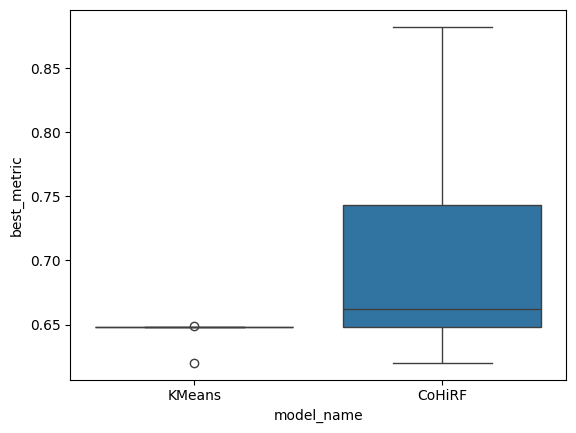

In [13]:
# summarize results in boxplot
sns.boxplot(data=df_results, x="model_name", y="best_metric")

# Partial features

In [14]:
def training_fn_partial_features_agents(trial, X, y, model_class, model_params, features_groups):
    model_params = flatten_any(model_params)
    trial_model_params = trial.params
    model_params = update_recursively(model_params, trial_model_params)
    model_params = unflatten_any(model_params)
    model = model_class(**model_params)
    if hasattr(model, "random_state"):
        model.random_state = trial.user_attrs["random_seed"]
    elif hasattr(model, "seed"):
        model.seed = trial.user_attrs["random_seed"]
    elif hasattr(model, "random_seed"):
        model.random_seed = trial.user_attrs["random_seed"]
    aris = []
    for feature_group in features_groups:
        y_pred = model.fit_predict(X.iloc[:, feature_group])
        ari = adjusted_rand_score(y, y_pred)
        aris.append(ari)
    ari = np.mean(aris)
    return dict(ari=ari)

In [15]:
def training_fn_partial_features_colab(trial, X, y, model_class, model_params, features_groups):
    model_params = flatten_any(model_params)
    trial_model_params = trial.params
    model_params = update_recursively(model_params, trial_model_params)
    model_params = unflatten_any(model_params)
    model = model_class(**model_params)
    if hasattr(model, "random_state"):
        model.random_state = trial.user_attrs["random_seed"]
    elif hasattr(model, "seed"):
        model.seed = trial.user_attrs["random_seed"]
    elif hasattr(model, "random_seed"):
        model.random_seed = trial.user_attrs["random_seed"]
    y_pred = model.fit_predict(X, features_groups)
    ari = adjusted_rand_score(y, y_pred)
    return dict(ari=ari)

In [16]:
def get_best_metric_partial_features(model_class, model_params, search_space, default_values, dataset_id, metric, direction, seed, features_groups, colab=False):
    X, y = get_X_y(dataset_id, standardize=True, seed_dataset_order=seed)
    random_generator = np.random.default_rng(seed)
    get_trial_partial = partial(get_trial, random_generator=random_generator)
    tuner = OptunaTuner(
        sampler="tpe",
        pruner=None,
        n_trials=30,
        seed=seed,
    )
    training_fn_partial_features = training_fn_partial_features_colab if colab else training_fn_partial_features_agents
    study = tuner.tune(
        training_fn=training_fn_partial_features,
        get_trial_fn=get_trial_partial,
        search_space=search_space,
        metric=metric,
        direction=direction,
        enqueue_configurations=default_values,
        X=X,
        y=y,
        model_class=model_class,
        model_params=deepcopy(model_params),
        features_groups=features_groups,
    )
    return study.best_value

In [17]:
seeds = [i for i in range(10)]
dataset_id = 61  # iris
metric = "ari"
direction = "maximize"
results = []
features_groups = [[0, 1], [1, 2]]

In [18]:
model_name = "KMeans"
model_class = KMeans
model_params = dict()
search_space = dict(n_clusters=opt.distributions.IntDistribution(2, 10))
default_values = [dict(n_clusters=3)]
colab = False

In [19]:
for seed in seeds:
    best_metric = get_best_metric_partial_features(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
        features_groups,
        colab=colab,
    )
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [20]:
model_name = "DistributedKMeans"
model_class = DistributedKMeans
model_params = dict()
search_space = dict(kmeans_n_clusters=opt.distributions.IntDistribution(2, 10))
default_values = [dict(n_clusters=3)]
colab = True

In [21]:
for seed in seeds:
    best_metric = get_best_metric_partial_features(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
        features_groups,
        colab=colab,
    )
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [22]:
model_name = "VeCoHiRF"
model_class = VeCoHiRF
model_params = dict(cohirf_kwargs=dict(base_model=KMeans))
search_space = dict(
	cohirf_kwargs=dict(
        base_model_kwargs=dict(n_clusters=opt.distributions.IntDistribution(2, 10)),
        repetitions=opt.distributions.IntDistribution(1, 10),
        n_features=opt.distributions.IntDistribution(1, 4),
    )
)
default_values = [dict(base_model_kwargs=dict(n_clusters=3), repetitions=1, n_features=4)]
colab = True

In [23]:
for seed in seeds:
    best_metric = get_best_metric_partial_features(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
        features_groups,
        colab=colab,
    )
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate po

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

...

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [24]:
df_results = pd.DataFrame(results)
df_results

,model_name,dataset_id,seed,best_metric,metric,direction
0,KMeans,61,0,0.531006,ari,maximize
1,KMeans,61,1,0.531006,ari,maximize
2,KMeans,61,2,0.531006,ari,maximize
3,KMeans,61,3,0.531006,ari,maximize
4,KMeans,61,4,0.532205,ari,maximize
5,KMeans,61,5,0.531006,ari,maximize
6,KMeans,61,6,0.531006,ari,maximize
7,KMeans,61,7,0.531938,ari,maximize
8,KMeans,61,8,0.531938,ari,maximize
9,KMeans,61,9,0.531006,ari,maximize


<Axes: xlabel='model_name', ylabel='best_metric'>

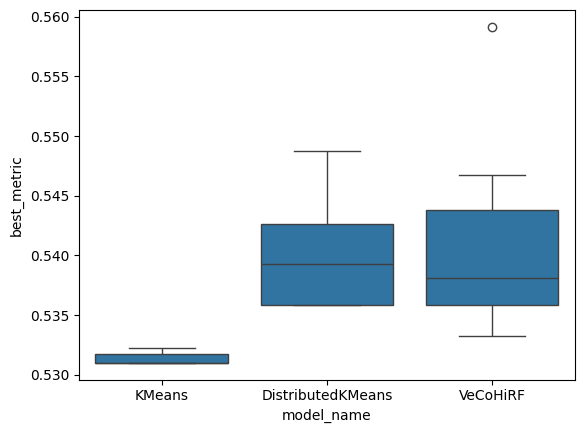

In [25]:
sns.boxplot(data=df_results, x="model_name", y="best_metric")

# Partial Samples

In [26]:
def training_fn_partial_samples_and_features(trial, X, y, model_class, model_params, samples_groups, features_groups, overlap_samples=None):
    model_params = flatten_any(model_params)
    trial_model_params = trial.params
    model_params = update_recursively(model_params, trial_model_params)
    model_params = unflatten_any(model_params)
    model = model_class(**model_params)
    if hasattr(model, "random_state"):
        model.random_state = trial.user_attrs["random_seed"]
    elif hasattr(model, "seed"):
        model.seed = trial.user_attrs["random_seed"]
    elif hasattr(model, "random_seed"):
        model.random_seed = trial.user_attrs["random_seed"]
    aris = []
    aris_overlap = []
    for i in range(len(samples_groups)):
        sample_group = samples_groups[i]
        feature_group = features_groups[i]
        X_sub = X.iloc[sample_group, feature_group]
        y_sub = y.iloc[sample_group]
        y_pred = model.fit_predict(X_sub)
        ari = adjusted_rand_score(y_sub, y_pred)
        aris.append(ari)
        if overlap_samples is not None:
            y_overlap = y.iloc[overlap_samples]
            y_pred_overlap = y_pred[overlap_samples]
            ari_overlap = adjusted_rand_score(y_overlap, y_pred_overlap)
            aris_overlap.append(ari_overlap)
    ari = np.mean(aris)
    ari_overlap = np.mean(aris_overlap) if overlap_samples is not None else None
    return dict(ari=ari, ari_overlap=ari_overlap)

In [27]:
def training_fn_partial_samples_and_features_colab(trial, X, y, model_class, model_params, samples_groups, features_groups, overlap_samples=None):
    model_params = flatten_any(model_params)
    trial_model_params = trial.params
    model_params = update_recursively(model_params, trial_model_params)
    model_params = unflatten_any(model_params)
    model = model_class(**model_params)
    if hasattr(model, "random_state"):
        model.random_state = trial.user_attrs["random_seed"]
    elif hasattr(model, "seed"):
        model.seed = trial.user_attrs["random_seed"]
    elif hasattr(model, "random_seed"):
        model.random_seed = trial.user_attrs["random_seed"]
    y_pred = model.fit_predict(X, samples_groups=samples_groups, features_groups=features_groups)
    ari = adjusted_rand_score(y, y_pred)
    if overlap_samples is not None:
        y_overlap = y.iloc[overlap_samples]
        y_pred_overlap = y_pred[overlap_samples]
        ari_overlap = adjusted_rand_score(y_overlap, y_pred_overlap)
    else:
        ari_overlap = None
    return dict(ari=ari, ari_overlap=ari_overlap)

In [28]:
def get_best_metric_partial_samples_and_features(model_class, model_params, search_space, default_values, dataset_id, metric, direction, seed, samples_groups, features_groups, colab=False, overlap_samples=None):
    X, y = get_X_y(dataset_id, standardize=True, seed_dataset_order=seed)
    random_generator = np.random.default_rng(seed)
    get_trial_partial = partial(get_trial, random_generator=random_generator)
    tuner = OptunaTuner(
        sampler="tpe",
        pruner=None,
        n_trials=30,
        seed=seed,
    )
    training_fn_partial = (
        training_fn_partial_samples_and_features_colab if colab else training_fn_partial_samples_and_features
    )
    study = tuner.tune(
        training_fn=training_fn_partial,
        get_trial_fn=get_trial_partial,
        search_space=search_space,
        metric=metric,
        direction=direction,
        enqueue_configurations=default_values,
        X=X,
        y=y,
        model_class=model_class,
        model_params=deepcopy(model_params),
        features_groups=features_groups,
        samples_groups=samples_groups,
        overlap_samples=overlap_samples,
    )
    return study

In [29]:
dataset = openml.datasets.get_dataset(dataset_id)
X, y = get_X_y(dataset_id, standardize=True, seed_dataset_order=seed)

In [30]:
seeds = [i for i in range(10)]
dataset_id = 61  # iris
metric = "ari"
direction = "maximize"
results = []
features_groups = [[0, 1, 2, 3], [0, 1, 2, 3]]
samples_groups = [np.array(range(0, X.shape[0] // 2)), np.array(range(X.shape[0] // 2 - 50, X.shape[0]))]
overlap_samples = np.array(range(X.shape[0] // 2 - 50, X.shape[0] // 2))

In [31]:
model_name = "KMeans"
model_class = KMeans
model_params = dict()
search_space = dict(n_clusters=opt.distributions.IntDistribution(2, 10))
default_values = [dict(n_clusters=3)]
colab = False

In [32]:
for seed in seeds:
    study = get_best_metric_partial_samples_and_features(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
        samples_groups,
        features_groups,
        colab=colab,
        overlap_samples=overlap_samples,
    )
    best_metric = study.best_value
    best_metric_overlap = study.best_trial.user_attrs["result"][f"{metric}_overlap"]
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        best_metric_overlap=best_metric_overlap,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [33]:
model_name = "MixCoHiRF"
model_class = MixCoHiRF
model_params = dict(cohirf_kwargs=dict(base_model=KMeans))
search_space = dict(
	cohirf_kwargs=dict(
        base_model_kwargs=dict(n_clusters=opt.distributions.IntDistribution(2, 10)),
        repetitions=opt.distributions.IntDistribution(1, 10),
        n_features=opt.distributions.IntDistribution(1, 4),
    )
)
default_values = [dict(base_model_kwargs=dict(n_clusters=3), repetitions=1, n_features=4)]
colab = True

In [34]:
for seed in seeds:
    study = get_best_metric_partial_samples_and_features(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
        samples_groups,
        features_groups,
        colab=colab,
        overlap_samples=overlap_samples,
    )
    best_metric = study.best_value
    best_metric_overlap = study.best_trial.user_attrs["result"][f"{metric}_overlap"]
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        best_metric_overlap=best_metric_overlap,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate point

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (10). Possibly due to duplicate po

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

...

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate point

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate point

In [35]:
df_results = pd.DataFrame(results)
df_results

,model_name,dataset_id,seed,best_metric,best_metric_overlap,metric,direction
0,KMeans,61,0,0.589203,0.256365,ari,maximize
1,KMeans,61,1,0.578234,0.279668,ari,maximize
2,KMeans,61,2,0.656676,0.297345,ari,maximize
3,KMeans,61,3,0.677395,0.340983,ari,maximize
4,KMeans,61,4,0.639582,0.306233,ari,maximize
5,KMeans,61,5,0.584477,0.256503,ari,maximize
6,KMeans,61,6,0.605028,0.281008,ari,maximize
7,KMeans,61,7,0.650329,0.340676,ari,maximize
8,KMeans,61,8,0.647586,0.330488,ari,maximize
9,KMeans,61,9,0.670243,0.340218,ari,maximize


<Axes: xlabel='model_name', ylabel='best_metric'>

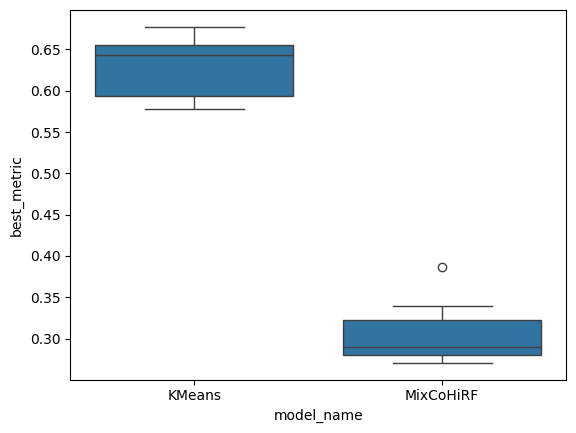

In [36]:
sns.boxplot(data=df_results, x="model_name", y="best_metric")

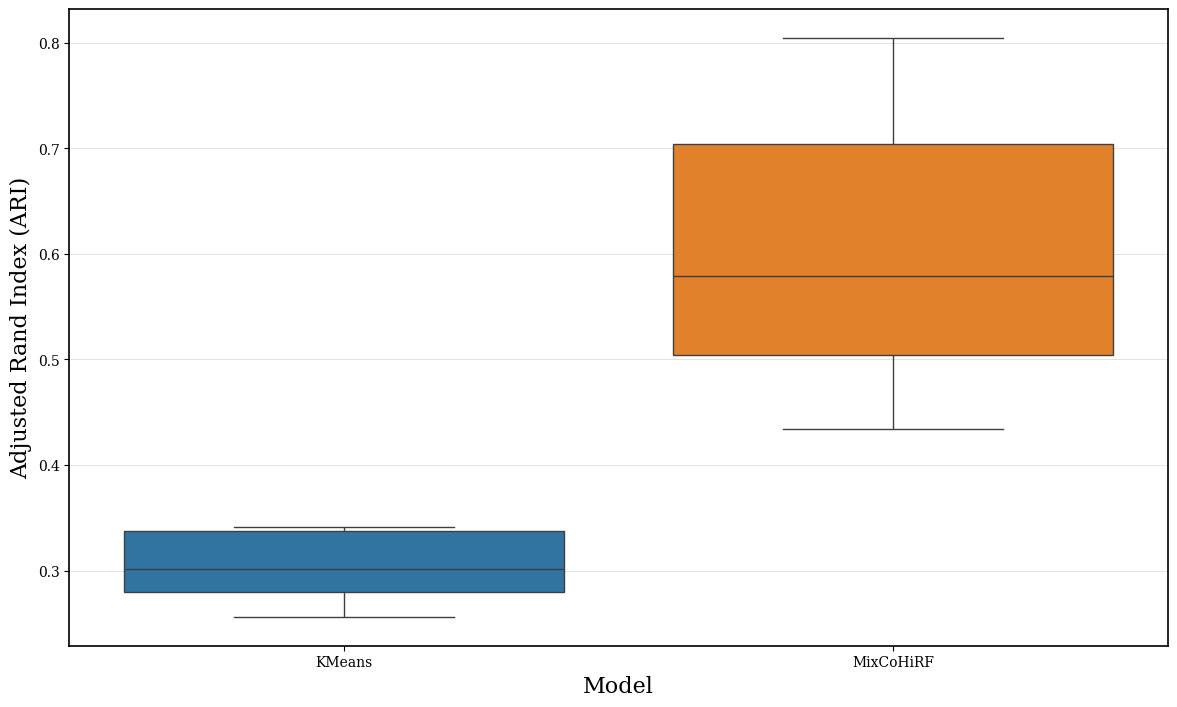

In [37]:
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    ax = sns.boxplot(data=df_results, x="model_name", hue="model_name", y="best_metric_overlap", ax=ax)
    ax.set_xlabel("Model")
    ax.set_ylabel("Adjusted Rand Index (ARI)")
    fig.savefig(
        results_dir / "mixcohirf_example_boxplot_best_metric_overlap_partial_samples.pdf",
        bbox_inches="tight",
    )

# Partial Samples and Features

In [38]:
dataset = openml.datasets.get_dataset(dataset_id)
X, y = get_X_y(dataset_id, standardize=True, seed_dataset_order=seed)

In [39]:
seeds = [i for i in range(10)]
dataset_id = 61  # iris
metric = "ari"
direction = "maximize"
results = []
features_groups = [[0, 1], [2, 3]]
samples_groups = [np.array(range(0, X.shape[0] // 2)), np.array(range(X.shape[0] // 2 - 50, X.shape[0]))]
overlap_samples = np.array(range(X.shape[0] // 2 - 50, X.shape[0] // 2))

In [40]:
model_name = "KMeans"
model_class = KMeans
model_params = dict()
search_space = dict(n_clusters=opt.distributions.IntDistribution(2, 10))
default_values = [dict(n_clusters=3)]
colab = False

In [41]:
for seed in seeds:
    study = get_best_metric_partial_samples_and_features(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
        samples_groups,
        features_groups,
        colab=colab,
        overlap_samples=overlap_samples,
    )
    best_metric = study.best_value
    best_metric_overlap = study.best_trial.user_attrs["result"][f"{metric}_overlap"]
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        best_metric_overlap=best_metric_overlap,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [42]:
model_name = "MixCoHiRF"
model_class = MixCoHiRF
model_params = dict(cohirf_kwargs=dict(base_model=KMeans))
search_space = dict(
	cohirf_kwargs=dict(
        base_model_kwargs=dict(n_clusters=opt.distributions.IntDistribution(2, 10)),
        repetitions=opt.distributions.IntDistribution(1, 10),
        n_features=opt.distributions.IntDistribution(1, 4),
    )
)
default_values = [dict(base_model_kwargs=dict(n_clusters=3), repetitions=1, n_features=4)]
colab = True

In [43]:
for seed in seeds:
    study = get_best_metric_partial_samples_and_features(
        model_class,
        model_params,
        search_space,
        default_values,
        dataset_id,
        metric,
        direction,
        seed,
        samples_groups,
        features_groups,
        colab=colab,
        overlap_samples=overlap_samples,
    )
    best_metric = study.best_value
    best_metric_overlap = study.best_trial.user_attrs["result"][f"{metric}_overlap"]
    result = dict(
        model_name=model_name,
        dataset_id=dataset_id,
        seed=seed,
        best_metric=best_metric,
        best_metric_overlap=best_metric_overlap,
        metric=metric,
        direction=direction,
    )
    results.append(result)

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate point

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (10). Possibly due to duplicate p

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

...

/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/belucci/miniconda3/envs/cocohirf/lib/python3.11/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate p

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

Trials:   0%|          | 0/30 [00:00<?, ?it/s]

In [44]:
df_results = pd.DataFrame(results)
df_results

,model_name,dataset_id,seed,best_metric,best_metric_overlap,metric,direction
0,KMeans,61,0,0.691123,0.203972,ari,maximize
1,KMeans,61,1,0.684833,0.265700,ari,maximize
2,KMeans,61,2,0.748940,0.311824,ari,maximize
3,KMeans,61,3,0.741936,0.265105,ari,maximize
4,KMeans,61,4,0.699446,0.235551,ari,maximize
5,KMeans,61,5,0.655628,0.197210,ari,maximize
6,KMeans,61,6,0.697073,0.263432,ari,maximize
7,KMeans,61,7,0.717627,0.309682,ari,maximize
8,KMeans,61,8,0.764746,0.295099,ari,maximize
9,KMeans,61,9,0.764864,0.302743,ari,maximize


<Axes: xlabel='model_name', ylabel='best_metric'>

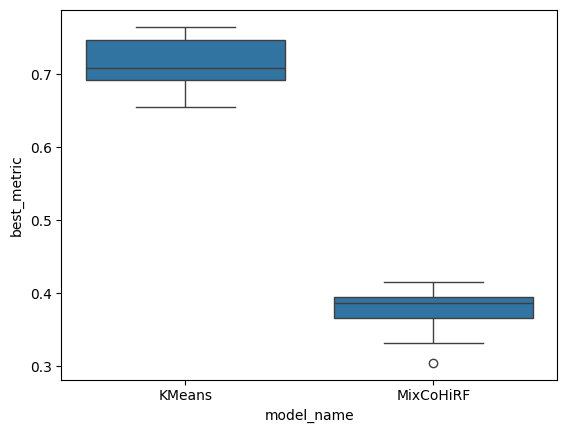

In [45]:
sns.boxplot(data=df_results, x="model_name", y="best_metric")

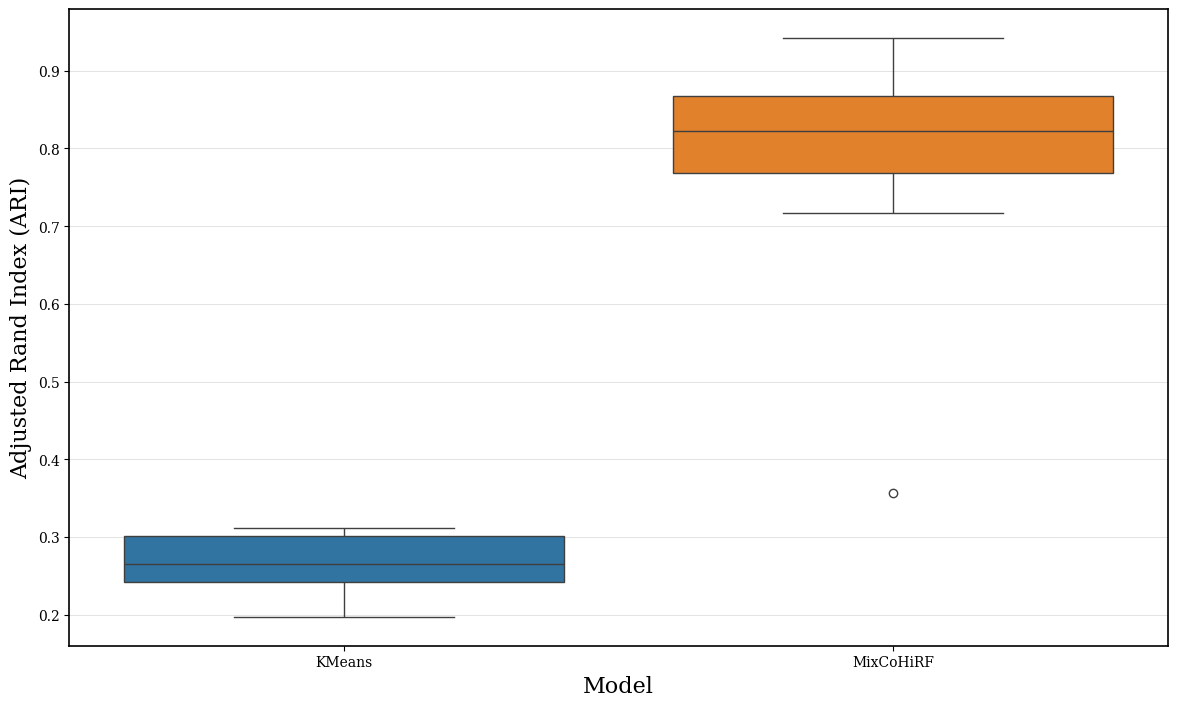

In [46]:
with mpl.rc_context(
        rc={
            "font.family": "serif",
            "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
            "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
            "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
            "font.size": 12,
            "axes.linewidth": 1.2,
            "axes.labelsize": 16,
            "axes.titlesize": 16,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "legend.frameon": True,
            "legend.fancybox": False,
            "legend.shadow": False,
            "legend.framealpha": 0.9,
            "legend.edgecolor": "black",
            "grid.alpha": 0.5,
            "axes.grid": True,
            "grid.linewidth": 0.5,
        }
    ):
        cm = 1 / 2.54  # centimeters to inches
        fig_scale = 3.0
        fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
        ax = sns.boxplot(data=df_results, x="model_name", hue="model_name", y="best_metric_overlap", ax=ax)
        ax.set_xlabel("Model")
        ax.set_ylabel("Adjusted Rand Index (ARI)")
        fig.savefig(results_dir / "mixcohirf_example_boxplot_best_metric_overlap_partial_features_and_samples.pdf", bbox_inches="tight")
        